# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
email = 'jmontoyo.soler@gmail.com'  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/jmontoyo.soler@gmail.com/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: Carga los datos y explica qué contiene el archivo.
# data = pd.read_csv(...)

# TODO: Muestra número de filas, columnas y variable objetivo.
# Carga de los datos
data = pd.read_csv("/Workspace/Users/jmontoyo.soler@gmail.com/clase_mlops_mlflow/data/raw/heart.csv")

# Información básica del dataset
print("Número de filas:", data.shape[0])
print("Número de columnas:", data.shape[1])

# Variable objetivo
print("Variable objetivo: ...")


Número de filas: 303
Número de columnas: 14
Variable objetivo: ...


In [0]:
# TODO: Muestra las primeras filas con head().
# TODO: Explica por qué esta inspección es útil antes de modelar.

data.head()
#es util por que podemos ver las variables, como estan los datos y sus caracteristicas


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: Usa info() para revisar tipos de datos y valores nulos.
data.info()

# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.
#las de tipo object son las categoricas y las int64 y float64 son las numericas


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
data.describe()

# TODO: Escribe observaciones sobre rangos, medias y posibles valores atípicos.
#la edad media es de 54 años con valores entre 29 y 77
## El colesterol tiene una media de 245.87 y valores entre 131 y 564
## oldpeak tiene una media de 1.04 y un máximo de 6.2,


,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes
- El rango de valores de cada característica
- La presencia de valores nulos
- Características que pueden necesitar normalización

In [0]:
# TODO: Analiza la distribución de la variable objetivo.
target_counts = data.target.value_counts()
print(target_counts)

# TODO: Calcula proporciones por clase.
# Proporciones por clase
target_proportions = data.target.value_counts(normalize=True)
print(target_proportions)
# TODO: Decide si el dataset está balanceado y explica por qué importa.
# El dataset está bastante balanceado, ya que hay un 54.5% de clase 1 y un 45.5% de clase 0 que no es una gran diferencia 


target
1    165
0    138
Name: count, dtype: int64
target
1    0.544554
0    0.455446
Name: proportion, dtype: float64


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

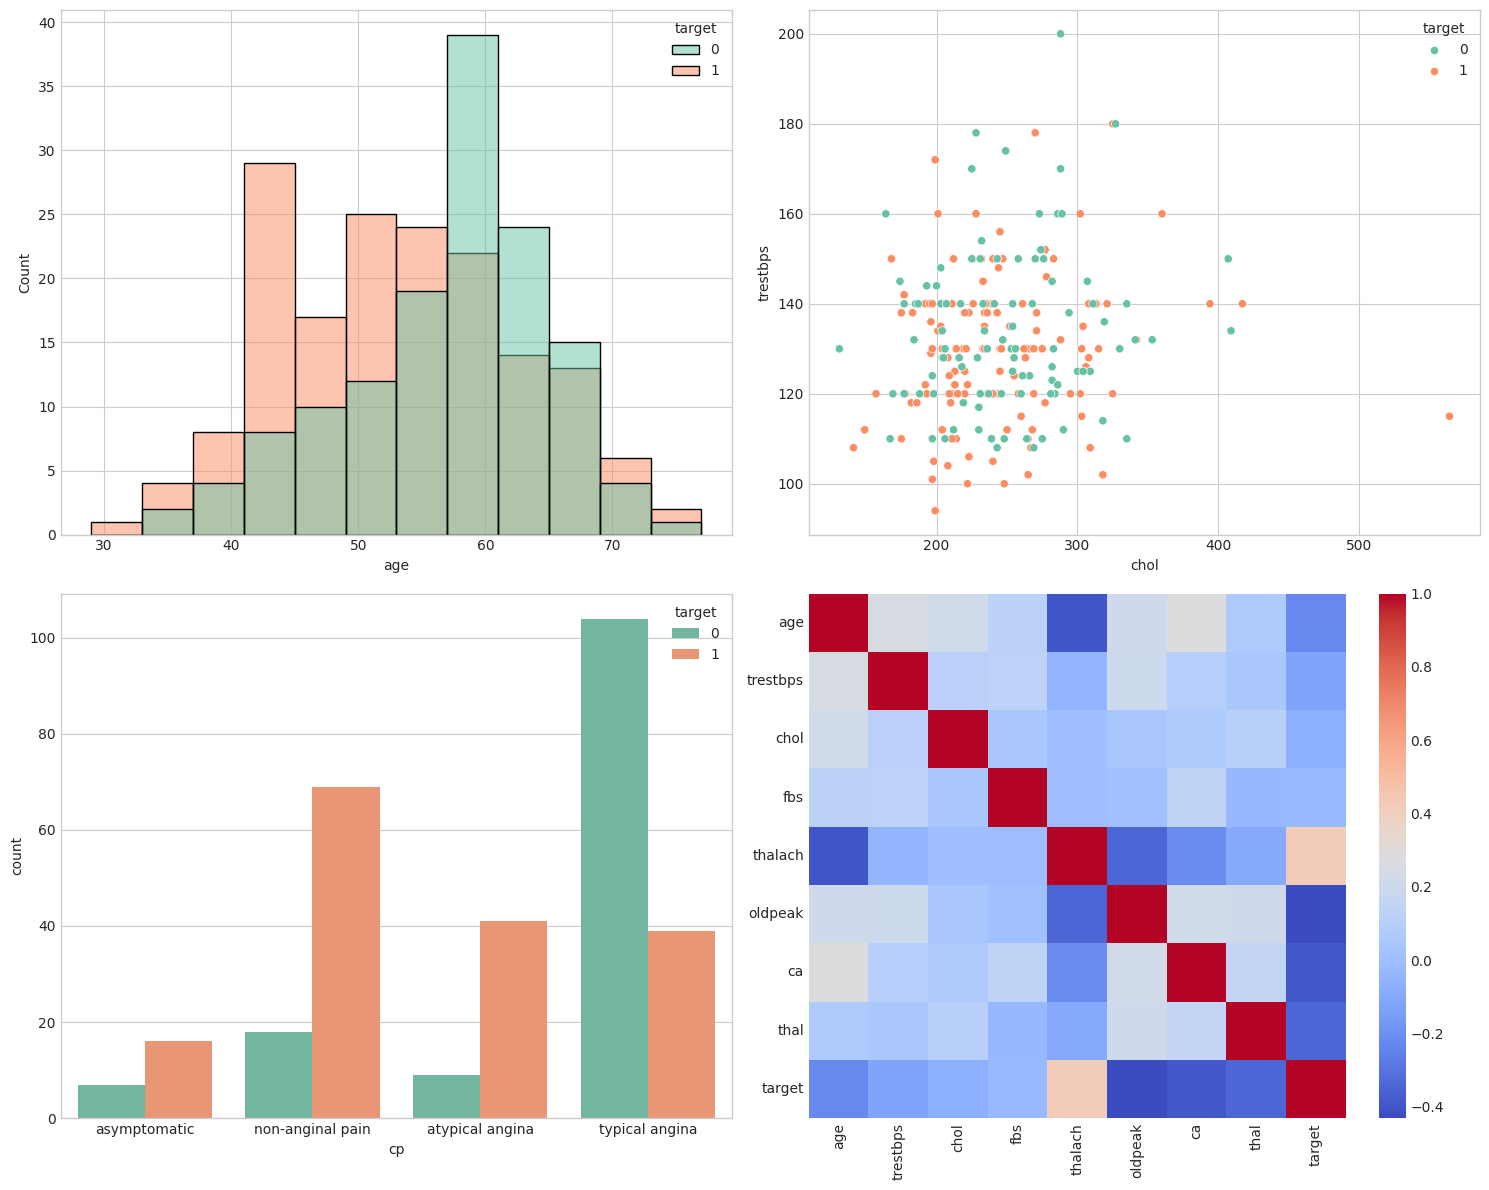

In [0]:
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# ...
# plt.show()
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribución de edad según diagnóstico
sns.histplot(data=data, x='age', hue='target', ax=axes[0,0])

# 2. Colesterol vs presión arterial según diagnóstico
sns.scatterplot(data=data, x='chol', y='trestbps',
                hue='target', ax=axes[0,1])

# 3. Tipo de dolor de pecho vs diagnóstico
sns.countplot(data=data, x='cp', hue='target', ax=axes[1,0])

# 4. Matriz de correlación
sns.heatmap(data.corr(numeric_only=True),
            ax=axes[1,1], cmap='coolwarm')

plt.tight_layout()
plt.show()

# TODO: Escribe qué patrones observas en los gráficos.

## La clase 1 aparece con mayor frecuencia en edades entre 40 y 55 años, y la clase 0 se centrra mas entre los 55 y 65.
# No se observa una relación clara entre el colesterol y la presión arterial
# El tipo de dolor de pecho parece estar relacionado con el diagnóstico.



## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad

# train_set, test_set = train_test_split(...)

# TODO: Comprueba el tamaño de cada conjunto.
from sklearn.model_selection import train_test_split

# Dividir los datos: 80% train y 20% test
train_set, test_set = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

# Comprobar tamaños
print("Train:", train_set.shape)
print("Test:", test_set.shape)


Train: (242, 14)
Test: (61, 14)


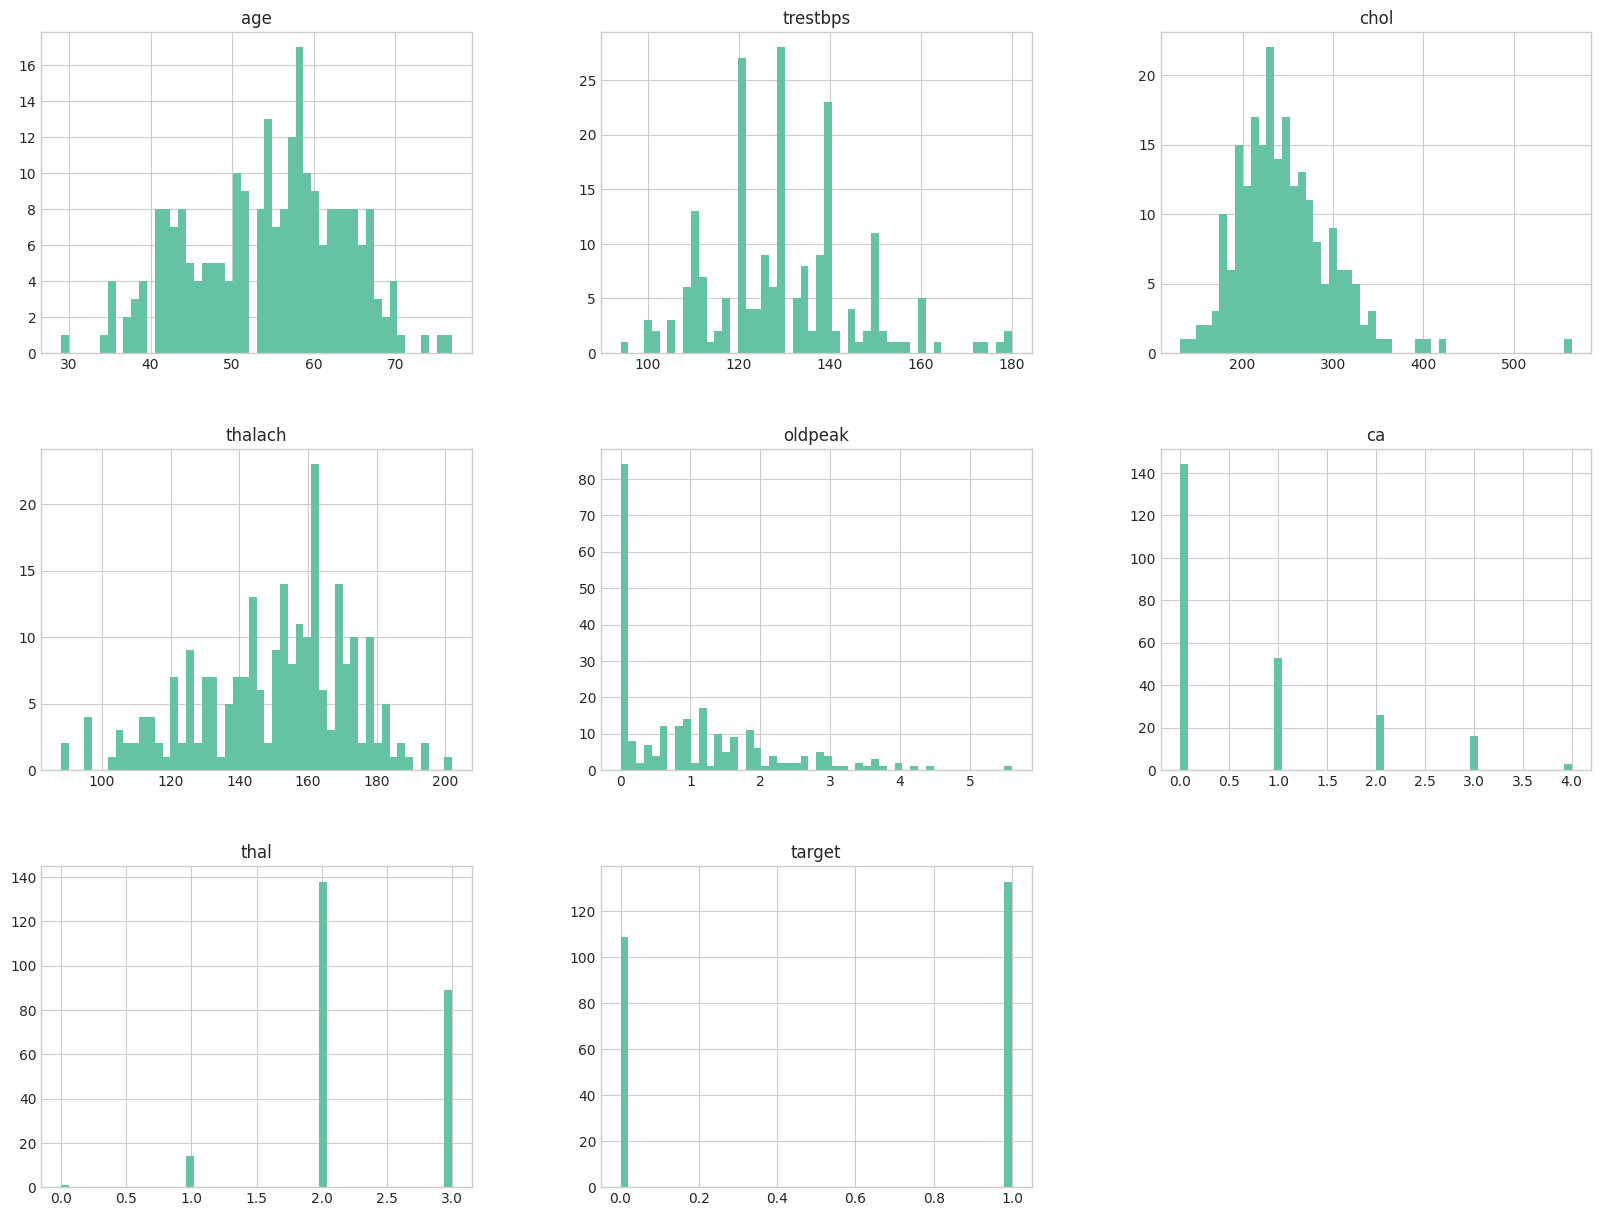

In [0]:
# TODO: Genera histogramas del conjunto de entrenamiento.

train_set.hist(bins=50, figsize=(20, 15))
plt.show()

# TODO: Identifica características con escalas o distribuciones muy diferentes.
# Se observan escalas muy diferentes entre las variables.
# Por ejemplo, chol llega a valores superiores a 500, mientras que oldpeak está entre 0 y 6 aproximadamente.


### 📏 Observación Importante: Escalas Diferentes

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

Las escalas diferentes pueden hacer que las variables con valores más grandes tengan mayor influencia en el modelo.


**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**

Aplicaría una estandarización con StandardScaler para poner las variables numéricas en una escala comparable.


**TODO: [Completa aquí] ¿Por qué esto ayuda a algunos modelos de Machine Learning?**

Esto ayuda a que ninguna variable domine por su escala y mejora el funcionamiento de modelos sensibles a las distancias o a la magnitud de las variables.


## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: Clasifica las columnas en categóricas y numéricas.
cat_attr = ['cp', 'thal']
num_attr = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attr),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attr)
])

# TODO: Explica por qué usamos One-Hot Encoding para categóricas.

# Usamos One-Hot Encoding porque las categorías no representan cantidades ni un orden.


## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
# x_train = ...
# y_train = ...

# TODO: Comprueba las dimensiones resultantes.

# Separar características (X) y variable objetivo (y)
X_train = train_set.drop('target', axis=1)
y_train = train_set['target']

# Comprobar dimensiones
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


X_train: (242, 13)
y_train: (242,)


In [0]:
# TODO: Aplica el pipeline al conjunto de entrenamiento.
# x_train_pr = full_pipeline.fit_transform(x_train)

# TODO: Explica la diferencia entre fit_transform y transform.
# fit_transform aprende los parámetros necesarios de los datos de entrenamiento y después realiza las transformaciones.

# transform solo aplica una transformación ya aprendida.

# El número de columnas puede aumentar porque OneHotEncoder convierte las variables categóricas en varias columnas binarias.

# TODO: Comprueba cómo cambia el número de columnas.

# Aplicar el pipeline
X_train_pr = full_pipeline.fit_transform(X_train)

# Comprobar cambio de dimensiones
print("Antes:", X_train.shape)
print("Después:", X_train_pr.shape)


Antes: (242, 13)
Después: (242, 14)


## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**
SGD es un método de optimización que entrena el modelo actualizando sus parámetros de forma iterativa para reducir el error

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# TODO: Activa autolog de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
#     TODO: Crea SGDClassifier.
    sgd_clf = SGDClassifier(random_state=42)
#
#     TODO: Evalúa con cross_val_score.
scores = cross_val_score(
        sgd_clf,
        X_train_pr,
        y_train,
        cv=5,
        scoring='accuracy'
    )
#
#     TODO: Registra métricas de validación cruzada en MLflow.
mlflow.log_metric("cv_accuracy_mean", scores.mean())
#
#     TODO: Interpreta el resultado obtenido.


---------------------------------------------------------------------------
Exception                                 Traceback (most recent call last)
File <command-5961220844510386>, line 5
      2 mlflow.sklearn.autolog()
      4 # TODO: Inicia un run para el modelo baseline SGD.
----> 5 with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
      6 #     TODO: Crea SGDClassifier.
      7     sgd_clf = SGDClassifier(random_state=42)
      8 #
      9 #     TODO: Evalúa con cross_val_score.

File /databricks/python/lib/python3.12/site-packages/mlflow/tracking/fluent.py:543, in start_run(run_id, experiment_id, run_name, nested, parent_run_id, tags, description, log_system_metrics)
    541 experiment_id = str(experiment_id) if isinstance(experiment_id, int) else experiment_id
    542 if len(active_run_stack) > 0 and not nested:
--> 543     raise Exception(
    544         (
    545             "Run with UUID {} is already active. To start a new run, first end the "
    546

### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: Obtén predicciones con validación cruzada.
preds = cross_val_predict( sgd_clf,
    X_train_pr,
    y_train,
    cv=5
)

print(preds)
# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.
#cross_val_predict genera una predicción para cada dato usando un modelo que no ha sido entrenado con ese dato entonces permite comparar con valores reales y calcular metricas y matriz de confusion


2026/10/01 15:43:32 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/3419645472912860/models/m-62407bdedbbe43c18149ca0ed1a962c8?o=7474656033369312
2026/10/01 15:43:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/3419645472912860/models/m-dddf102832df44a7b5c52f83f3586d66?o=7474656033369312
2026/10/01 15:43:45 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/3419645472912860/models/m-74d2b966b6d448f5990cc5e75d998ebf?o=7474656033369312
2026/10/01 15:43:51 WARNING mlflow

[1 0 0 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 1 0 0
 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 1
 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 1
 0 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0
 1 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 1 1 0 0 1
 0 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0 1 0 0 0 1 1 0
 0 1 1 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 0 1]


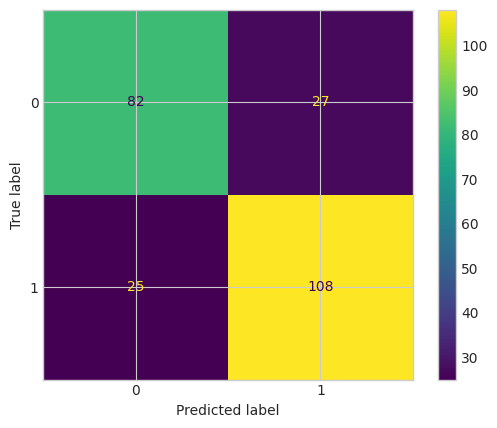

In [0]:
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.
cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

# TODO: Interpreta TN, FP, FN y TP.
# TN = 82 casos negativos correctamente clasificados.
# FP = 27 casos negativos clasificados incorrectamente como positivos.
# FN = 25 casos positivos clasificados incorrectamente como negativos.
# TP = 108 casos positivos correctamente clasificados.

# TODO: ¿Qué tipo de error es más grave en medicina?
#en medicina lo mas grve es dar un falso negativo 


In [0]:
# TODO: Calcula métricas del modelo SGD.
# precision = precision_score(...)
# recall = recall_score(...)
# f1 = f1_score(...)
# roc_auc = roc_auc_score(...)

# TODO: Imprime e interpreta las métricas.
# TODO: ¿Qué métrica es más importante en medicina y por qué?
# En este contexto médico, el recall es especialmente importante porque mide cuántos casos positivos reales consigue detectar el modelo.

precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

# Imprimir métricas
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
#precision- de los pacientes que el modelo clasifica como positivos, el 80% realmente lo son
#recall - detecta aproximadamente el 81% de los casos positivos reales.
# f1 -indica un buen equilibrio entre precision y recall.


Precision: 0.8
Recall: 0.8120300751879699
F1-score: 0.8059701492537313
ROC-AUC: 0.7821618265848106


### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:

mlflow.end_run()
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
with mlflow.start_run(run_name="Random Forest Classifier") as run:

    rf_clf = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_scores = cross_val_score(
        rf_clf,
        X_train_pr,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    rf_preds = cross_val_predict(
        rf_clf,
        X_train_pr,
        y_train,
        cv=5
    )

    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())

    print("Scores:", rf_scores)
    print("Accuracy media:", rf_scores.mean())
#
# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.

# Se pueden ajustar hiperparámetros como n_estimators, max_depth y min_samples_split para controlar el número y complejidad de los árboles.
# Lo comparamos con SGD para comprobar qué modelo obtiene mejores resultados sobre los mismos datos.


2026/10/01 15:53:24 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/3419645472912860/models/m-8034e97e207e4499ad438da3de1908de?o=7474656033369312
2026/10/01 15:53:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/3419645472912860/models/m-2eb3e0f7032b457f98319348fe19c6f0?o=7474656033369312
2026/10/01 15:53:35 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/3419645472912860/models/m-6e3c35a6980f4067a9b3dcb9dee61902?o=7474656033369312
2026/10/01 15:53:41 WARNING mlflow

Scores: [0.79591837 0.79591837 0.77083333 0.85416667 0.85416667]
Accuracy media: 0.8142006802721088


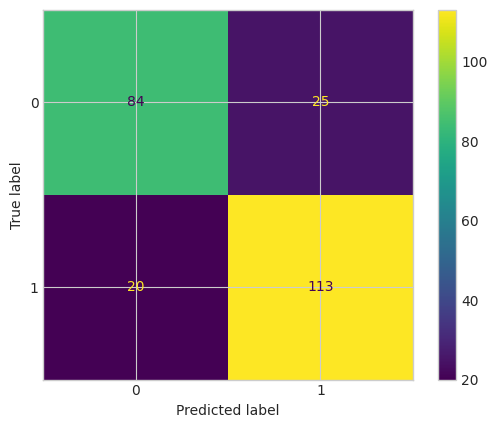

SGD:
[[ 82  27]
 [ 25 108]]
Random Forest:
[[ 84  25]
 [ 20 113]]


In [0]:
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
cm_rf = confusion_matrix(y_train, rf_preds)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()

plt.show()

# TODO: Compara los errores con los del modelo SGD.

print("SGD:")
print(confusion_matrix(y_train, preds))

print("Random Forest:")
print(cm_rf)

In [0]:
# TODO: Calcula métricas de Random Forest.
rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC-AUC:", rf_roc_auc)
# TODO: Crea una tabla comparativa SGD vs Random Forest.
comparacion = pd.DataFrame({
    "SGD": [precision, recall, f1, roc_auc],
    "Random Forest": [rf_precision, rf_recall, rf_f1, rf_roc_auc]
}, index=["Precision", "Recall", "F1", "ROC-AUC"])

print(comparacion)
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.
# En esta evaluación, Random Forest obtiene mejores resultados que SGD, ya que presenta valores mayores de precision, recall, F1 y ROC-AUC.


Precision: 0.8188405797101449
Recall: 0.849624060150376
F1: 0.8339483394833949
ROC-AUC: 0.8101331309926192
                SGD  Random Forest
Precision  0.800000       0.818841
Recall     0.812030       0.849624
F1         0.805970       0.833948
ROC-AUC    0.782162       0.810133


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
forest_clf = RandomForestClassifier( n_estimators=100, random_state=42)
forest_clf.fit(X_train_pr, y_train)

# TODO: Explica por qué ahora entrenamos con todos los datos de train.
# Ahora entrenamos con todos los datos de train porque ya hemos evaluado y seleccionado el modelo mediante validación cruzada.


2026/10/01 15:57:28 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f976ed21f2074689841f3be9e39dd865', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 15:57:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/3419645472912860/models/m-9ded9e55a0214741b628cb62c63580b4?o=7474656033369312


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [0]:
# TODO: Separa características y target del conjunto de prueba.
X_test = test_set.drop('target', axis=1)
y_test = test_set['target']

# TODO: Comprueba dimensiones.
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_test: (61, 13)
y_test: (61,)


In [0]:
# TODO: Transforma el conjunto de prueba y genera predicciones.
x_test_pr = full_pipeline.transform(X_test)
final_preds = forest_clf.predict(x_test_pr)

# TODO: Explica por qué usamos transform() y no fit_transform() en test.
# Usamos transform() porque el pipeline ya   parámetros utilizando los datos de entrenamiento.


Accuracy: 0.8524590163934426
Precision: 0.8484848484848485
Recall: 0.875
F1: 0.8615384615384616
ROC-AUC: 0.8512931034482758


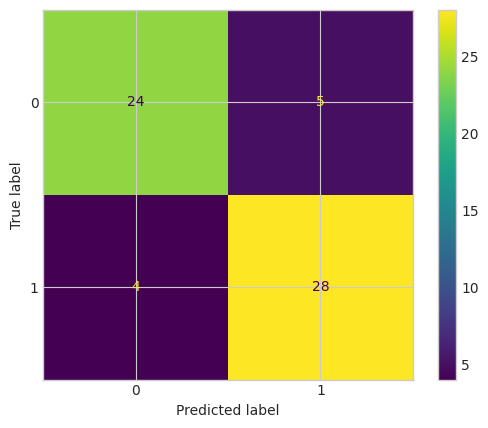

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [0]:
# TODO: Evalúa resultados finales en el conjunto de prueba.


# TODO: Visualiza la matriz de confusión final.
# TODO: Genera classification_report.
# TODO: Interpreta si el modelo generaliza bien.

# Métricas finales
final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

print("Accuracy:", final_accuracy)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1:", final_f1)
print("ROC-AUC:", final_roc_auc)

# Matriz de confusión
cm_final = confusion_matrix(y_test, final_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_final)
disp.plot()
plt.show()

# Classification report
print(classification_report(y_test, final_preds))


## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - random forest por que ha obtenido mejores resultados que SGD en las metricas evaluadas 

2. **¿Por qué crees que funcionó mejor?**
   - Random Forest puede capturar relaciones más complejas y no lineales entre las variables

3. **¿El modelo es suficientemente bueno para uso médico?**
   - no se podria decir si es suficientemente bueno, tendriamos que validarlo con mas datos

4. **¿Qué métrica es más importante en este caso?**
   - el recall por que mide que prpoporcion de pacientes positivosm detectamos 

5. **¿Qué mejorarías del modelo?**
   - Ajustaría hiperparámetros de Random Forest como n_estimators, max_depth y min_samples_split

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   -  falsos negativos por que al paciente se le dice que no tiene una enfermedad cuando si la tiene y no es tratada 

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - no, deberia de estar revisado por un medico 

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - para poder tomar decisiones conjuntas optimas 

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
# from sklearn.metrics import roc_curve, auc
# y_proba = ...
# fpr, tpr, thresholds = roc_curve(...)
# TODO: visualiza la curva ROC.

# ========================================
# TODO: DESAFÍO 3 - Importancia de características
# ========================================
# feature_names = ...
# feature_importance = ...
# TODO: identifica e interpreta las características más importantes.

# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena, evalúa y registra cada modelo en MLflow
#     pass
